In [1]:
pip install seaborn scipy

In [4]:
!python eda.py

DATASET OVERVIEW
  Shape          : 231,027 rows × 13 columns
  Simulations    : 5,000
  Breach rate    : 40.0%
  Missing values : 0

sim_id                       int64
num_doctors                  int64
num_triage_nurses            int64
num_beds                     int64
arrival_rate               float64
lab_capacity                 int64
triage_level                 int64
needs_lab                    int64
arrival_hour               float64
queue_length_on_arrival      int64
wait_for_doctor_mins       float64
total_time_mins            float64
breached                     int64
dtype: object

                            count     mean      std  ...      50%      75%      max
sim_id                   231027.0  2518.32  1450.42  ...  2521.00  3784.00  4999.00
num_doctors              231027.0     3.93     1.38  ...     4.00     5.00     6.00
num_triage_nurses        231027.0     2.16     1.08  ...     2.00     3.00     4.00
num_beds                 231027.0     8.67     1.97  ...    

In [5]:
import pandas as pd
from sklearn.model_selection import train_test_split
from xgboost import XGBClassifier

# Load data
df = pd.read_csv("ed_dataset_engineered.csv")

# Drop leakage features
df = df.drop(columns=["wait_for_doctor_mins", "total_time_mins"], errors="ignore")

# Drop NaN target
df = df.dropna(subset=["breached"])

X = df.drop(["breached", "sim_id"], axis=1, errors="ignore")
y = df["breached"]

# Split
X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42, stratify=y_temp)

# Model
model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42)

model.fit(X_train, y_train, eval_set=[(X_val, y_val)], verbose=True)

[0]	validation_0-logloss:0.65015
[1]	validation_0-logloss:0.63215
[2]	validation_0-logloss:0.61306
[3]	validation_0-logloss:0.60498
[4]	validation_0-logloss:0.58952
[5]	validation_0-logloss:0.57679
[6]	validation_0-logloss:0.56551
[7]	validation_0-logloss:0.55420
[8]	validation_0-logloss:0.54234
[9]	validation_0-logloss:0.53264
[10]	validation_0-logloss:0.52146
[11]	validation_0-logloss:0.51327
[12]	validation_0-logloss:0.50351
[13]	validation_0-logloss:0.49539
[14]	validation_0-logloss:0.48706
[15]	validation_0-logloss:0.48291
[16]	validation_0-logloss:0.47529
[17]	validation_0-logloss:0.46844
[18]	validation_0-logloss:0.46195
[19]	validation_0-logloss:0.45634
[20]	validation_0-logloss:0.45160
[21]	validation_0-logloss:0.44605
[22]	validation_0-logloss:0.44093
[23]	validation_0-logloss:0.43602
[24]	validation_0-logloss:0.43239
[25]	validation_0-logloss:0.42821
[26]	validation_0-logloss:0.42452
[27]	validation_0-logloss:0.42179
[28]	validation_0-logloss:0.41812
[29]	validation_0-loglos

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None,
              num_parallel_tree=None, ...)

In [8]:
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)
# Probabilities
y_prob = model.predict_proba(X_test)[:, 1]

# ROC values
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

              precision    recall  f1-score   support

           0       0.87      0.88      0.88     20787
           1       0.82      0.81      0.81     13868

    accuracy                           0.85     34655
   macro avg       0.85      0.84      0.85     34655
weighted avg       0.85      0.85      0.85     34655

ROC-AUC: 0.929946044826307


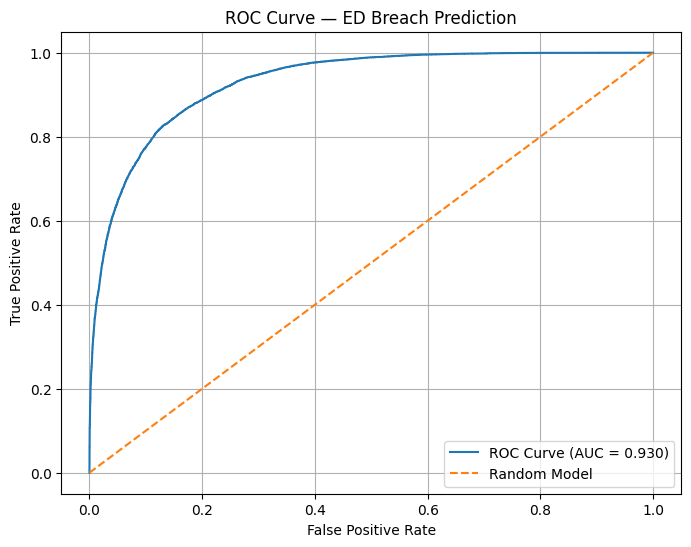

In [9]:
plt.figure(figsize=(8,6))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {roc_auc:.3f})")

plt.plot([0,1], [0,1], linestyle='--', label="Random Model")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — ED Breach Prediction")

plt.legend()
plt.grid()

plt.savefig("roc_curve.png", bbox_inches="tight", dpi=300)
plt.show()

In [10]:
pip install shap

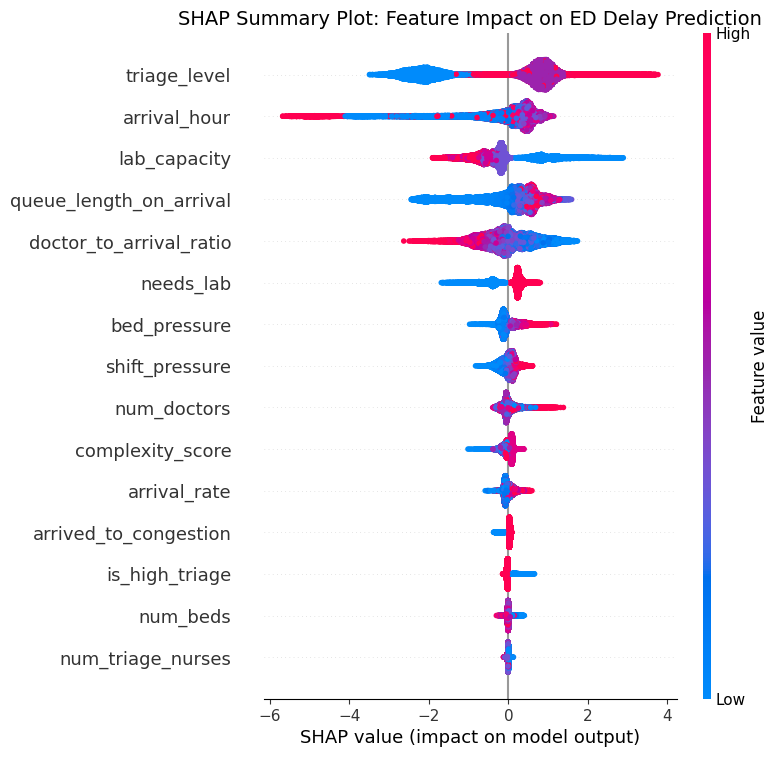

<Figure size 640x480 with 0 Axes>

In [11]:
import shap
import matplotlib.pyplot as plt


explainer = shap.Explainer(model)
shap_values = explainer(X_test)

plt.figure(figsize=(10, 7))
shap.summary_plot(shap_values, X_test, show=False)
plt.title("SHAP Summary Plot: Feature Impact on ED Delay Prediction", fontsize=14)
plt.show()
plt.savefig("shap_summary.png", bbox_inches="tight", dpi=300)

**What-if Analysis: Impact of Increasing Doctor Availability**

In [12]:
# Copy test data
X_test_whatif = X_test.copy()

# Increase doctors
X_test_whatif["num_doctors"] += 2

# Recompute dependent features
X_test_whatif["doctor_to_arrival_ratio"] = (
    X_test_whatif["num_doctors"] / X_test_whatif["arrival_rate"]
)

X_test_whatif["shift_pressure"] = (
    X_test_whatif["arrival_rate"] /
    (X_test_whatif["num_doctors"] * X_test_whatif["num_triage_nurses"])
)

# Predictions
orig_prob = model.predict_proba(X_test)[:, 1]
whatif_prob = model.predict_proba(X_test_whatif)[:, 1]

# Compare
import numpy as np

orig_rate = np.mean(orig_prob > 0.5)
whatif_rate = np.mean(whatif_prob > 0.5)

print(f"Original breach rate: {orig_rate:.2%}")
print(f"After +2 doctors: {whatif_rate:.2%}")
print(f"Reduction: {(orig_rate - whatif_rate):.2%}")

Original breach rate: 39.29%
After +2 doctors: 28.56%
Reduction: 10.73%


In [13]:
results = []

for d in [0, 1, 2, 3]:
    temp = X_test.copy()
    temp["num_doctors"] += d

    temp["doctor_to_arrival_ratio"] = temp["num_doctors"] / temp["arrival_rate"]
    temp["shift_pressure"] = temp["arrival_rate"] / (temp["num_doctors"] * temp["num_triage_nurses"])

    prob = model.predict_proba(temp)[:, 1]
    rate = np.mean(prob > 0.5)

    results.append((d, rate))

for d, r in results:
    print(f"+{d} doctors → breach rate: {r:.2%}")

+0 doctors → breach rate: 39.29%
+1 doctors → breach rate: 31.42%
+2 doctors → breach rate: 28.56%
+3 doctors → breach rate: 26.28%


**A real dataset comparison**

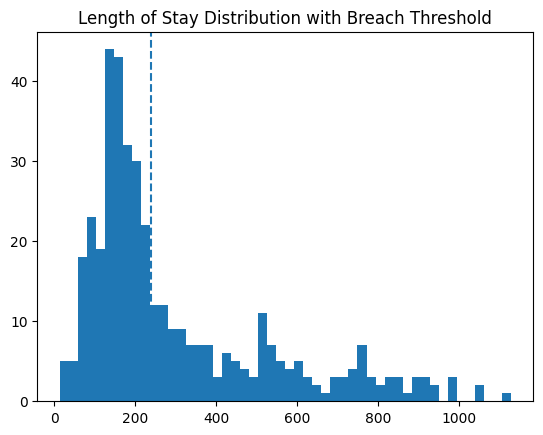

In [15]:
sim_df = pd.read_csv("test_simulation_output.csv")

plt.hist(sim_df["total_time_mins"], bins=50)
plt.axvline(x=240, linestyle='--')  # 4-hour breach line
plt.title("Length of Stay Distribution with Breach Threshold")
plt.show()

In [17]:
real_df = pd.read_csv("Hospital ER_Data.csv")
print(real_df.columns)

Index(['Patient Id', 'Patient Admission Date', 'Patient First Inital',
       'Patient Last Name', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime', 'Patients CM'],
      dtype='object')


In [18]:
real_df["Patient Waittime"] = pd.to_numeric(real_df["Patient Waittime"], errors="coerce")

# Clean
real_df = real_df.dropna(subset=["Patient Waittime"])
real_df = real_df[real_df["Patient Waittime"] > 0]
sim_wait = sim_df["wait_for_doctor_mins"]
real_wait = real_df["Patient Waittime"]

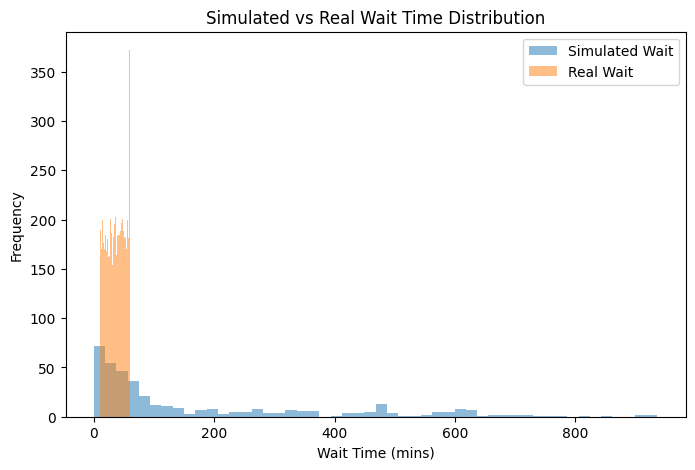

Sim mean wait: 184.99985221674876
Real mean wait: 35.25987413194444


In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

plt.hist(sim_wait, bins=50, alpha=0.5, label="Simulated Wait")
plt.hist(real_wait, bins=50, alpha=0.5, label="Real Wait")

plt.xlabel("Wait Time (mins)")
plt.ylabel("Frequency")
plt.title("Simulated vs Real Wait Time Distribution")
plt.legend()

plt.show()

print("Sim mean wait:", sim_wait.mean())
print("Real mean wait:", real_wait.mean())

The simulated mean wait time (185 minutes) is significantly higher than the real dataset (35 minutes). This difference is expected, as the simulation includes deliberately stressed scenarios with high arrival rates and constrained resources to generate sufficient delay events for model training.

Additionally, the real dataset captures only initial wait times, whereas the simulation models end-to-end system congestion, including doctor, bed, and lab delays.